# 1. Pre Processing
Lazımsız sütunları sil
Data-da 'Date of transaction' sütunu var. Onu pd.to_datetime istifadə edərək datetime tipinə çevir (dayfirst=True parametrini əlavə et)

Ondan aşağıdakı yeni sütunları yarat:

transaction_year
transaction_month
transaction_day

Məsələn:

data['column_name'].dt.year
data['column_name'].dt.month
data['column_name'].dt.day
Yuxarıdakı sütunları yaratdıqdan sonra 'Date of transaction' sütununu sil
Missing (çatışmayan) dəyərləri yoxla
LabelEncoder istifadə edərək original datadan new_data yarat (kategorik dəyişənləri numerikə çevir)
inputs-u new_data-dan, inputs_cat-ı isə original data-dan təyin et
Əgər inputs_cat-da missing varsa, onları 'Missing value' ilə doldur
Train-test split mərhələsi:
X_train, X_test, y_train, y_test
X_train_cat, X_test_cat, y_train_cat, y_test_cat yaradılmalıdır

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
sns.set()
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
data=pd.read_excel(r'C:\Users\TOSHIBA\Downloads\fraud_data.xlsx')
data.head()

,type,branch,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,unusuallogin,isFlaggedFraud,Acct type,Date of transaction,Time of day,isFraud
0,PAYMENT,Indonesia,9839.64,C1231006815,170136.0,160296.36,M1979787155,9,0,Current,3/1/2018,Morning,0
1,PAYMENT,India,1864.28,C1666544295,21249.0,19384.72,M2044282225,10,0,Savings,5/1/2018,Morning,0
2,TRANSFER,India,181.00,C1305486145,181.0,0.00,C553264065,2,0,Current,7/1/2018,Morning,1
3,CASH_OUT,Australia,181.00,C840083671,181.0,0.00,C38997010,1,0,Current,6/1/2018,Afternoon,1
4,PAYMENT,Australia,11668.14,C2048537720,41554.0,29885.86,M1230701703,17,0,Current,6/1/2018,Morning,0


In [3]:
data.describe(include='all')

,type,branch,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,unusuallogin,isFlaggedFraud,Acct type,Date of transaction,Time of day,isFraud
count,10125,10125,1.012500e+04,10125,1.012500e+04,1.012500e+04,10125,10125.000000,10125.0,10125,10125,10125,10125.000000
unique,5,135,NaN,10119,NaN,NaN,6494,NaN,NaN,2,14,3,NaN
top,PAYMENT,Estados Unidos,NaN,C10001825,NaN,NaN,C985934102,NaN,NaN,Savings,6/1/2018,Afternoon,NaN
freq,5544,1282,NaN,7,NaN,NaN,68,NaN,NaN,6995,1453,3628,NaN
mean,NaN,NaN,1.048873e+05,NaN,8.836949e+05,9.046314e+05,NaN,10.513580,0.0,NaN,NaN,NaN,0.011654
std,NaN,NaN,2.706366e+05,NaN,2.124555e+06,2.170130e+06,NaN,5.809393,0.0,NaN,NaN,NaN,0.107330
min,NaN,NaN,2.390000e+00,NaN,0.000000e+00,0.000000e+00,NaN,0.000000,0.0,NaN,NaN,NaN,0.000000
25%,NaN,NaN,4.397580e+03,NaN,1.290000e+02,0.000000e+00,NaN,6.000000,0.0,NaN,NaN,NaN,0.000000
50%,NaN,NaN,1.279882e+04,NaN,2.136300e+04,1.019179e+04,NaN,10.000000,0.0,NaN,NaN,NaN,0.000000
75%,NaN,NaN,1.143818e+05,NaN,1.724320e+05,1.707442e+05,NaN,16.000000,0.0,NaN,NaN,NaN,0.000000


In [4]:
data=data.drop(['branch','nameOrig','nameDest'],axis=1)

In [5]:
data['Date of transaction']=pd.to_datetime(data['Date of transaction'], dayfirst=True)

In [6]:
data['transaction_year']=data['Date of transaction'].dt.year
data['transaction_month']=data['Date of transaction'].dt.month
data['transaction_day']=data['Date of transaction'].dt.day
data

,type,amount,oldbalanceOrg,newbalanceOrig,unusuallogin,isFlaggedFraud,Acct type,Date of transaction,Time of day,isFraud,transaction_year,transaction_month,transaction_day
0,PAYMENT,9839.64,170136.0,160296.36,9,0,Current,2018-01-03,Morning,0,2018,1,3
1,PAYMENT,1864.28,21249.0,19384.72,10,0,Savings,2018-01-05,Morning,0,2018,1,5
2,TRANSFER,181.00,181.0,0.00,2,0,Current,2018-01-07,Morning,1,2018,1,7
3,CASH_OUT,181.00,181.0,0.00,1,0,Current,2018-01-06,Afternoon,1,2018,1,6
4,PAYMENT,11668.14,41554.0,29885.86,17,0,Current,2018-01-06,Morning,0,2018,1,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10120,PAYMENT,337.50,33107.0,32769.50,7,0,Current,2018-01-03,Afternoon,0,2018,1,3
10121,PAYMENT,5003.57,32769.5,27765.93,11,0,Savings,2018-01-05,Morning,0,2018,1,5
10122,PAYMENT,10424.89,50780.0,40355.11,6,0,Savings,2018-01-07,Night,0,2018,1,7
10123,PAYMENT,2823.59,986.0,0.00,12,0,Savings,2018-01-06,Night,0,2018,1,6


In [7]:
data=data.drop('Date of transaction',axis=1)

In [8]:
data.isnull().sum()

type                 0
amount               0
oldbalanceOrg        0
newbalanceOrig       0
unusuallogin         0
isFlaggedFraud       0
Acct type            0
Time of day          0
isFraud              0
transaction_year     0
transaction_month    0
transaction_day      0
dtype: int64

In [9]:
data_rf=data.copy()
new_data=data.copy()

In [10]:

from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
encoders={}
for i in new_data.select_dtypes(include='object').columns:
    new_data[i]=le.fit_transform(new_data[i])
    encoders[i]=le
new_data


C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_11676\2940213954.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for i in new_data.select_dtypes(include='object').columns:


,type,amount,oldbalanceOrg,newbalanceOrig,unusuallogin,isFlaggedFraud,Acct type,Time of day,isFraud,transaction_year,transaction_month,transaction_day
0,3,9839.64,170136.0,160296.36,9,0,0,1,0,2018,1,3
1,3,1864.28,21249.0,19384.72,10,0,1,1,0,2018,1,5
2,4,181.00,181.0,0.00,2,0,0,1,1,2018,1,7
3,1,181.00,181.0,0.00,1,0,0,0,1,2018,1,6
4,3,11668.14,41554.0,29885.86,17,0,0,1,0,2018,1,6
...,...,...,...,...,...,...,...,...,...,...,...,...
10120,3,337.50,33107.0,32769.50,7,0,0,0,0,2018,1,3
10121,3,5003.57,32769.5,27765.93,11,0,1,1,0,2018,1,5
10122,3,10424.89,50780.0,40355.11,6,0,1,2,0,2018,1,7
10123,3,2823.59,986.0,0.00,12,0,1,2,0,2018,1,6


In [11]:
encoders

{'type': LabelEncoder(),
 'Acct type': LabelEncoder(),
 'Time of day': LabelEncoder()}

In [12]:
new_data.columns

Index(['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'unusuallogin',
       'isFlaggedFraud', 'Acct type', 'Time of day', 'isFraud',
       'transaction_year', 'transaction_month', 'transaction_day'],
      dtype='str')

In [13]:
le=LabelEncoder()
for i in data_rf.columns:
    if data_rf[i].dtype=='str':
        data_rf[i]=le.fit_transform(data_rf[i])
        
data_rf


,type,amount,oldbalanceOrg,newbalanceOrig,unusuallogin,isFlaggedFraud,Acct type,Time of day,isFraud,transaction_year,transaction_month,transaction_day
0,3,9839.64,170136.0,160296.36,9,0,0,1,0,2018,1,3
1,3,1864.28,21249.0,19384.72,10,0,1,1,0,2018,1,5
2,4,181.00,181.0,0.00,2,0,0,1,1,2018,1,7
3,1,181.00,181.0,0.00,1,0,0,0,1,2018,1,6
4,3,11668.14,41554.0,29885.86,17,0,0,1,0,2018,1,6
...,...,...,...,...,...,...,...,...,...,...,...,...
10120,3,337.50,33107.0,32769.50,7,0,0,0,0,2018,1,3
10121,3,5003.57,32769.5,27765.93,11,0,1,1,0,2018,1,5
10122,3,10424.89,50780.0,40355.11,6,0,1,2,0,2018,1,7
10123,3,2823.59,986.0,0.00,12,0,1,2,0,2018,1,6


In [14]:
inputs_u = new_data.drop('isFraud', axis=1)
inputs_rf=data_rf.drop('isFraud',axis=1)
output = new_data['isFraud']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(inputs_u, output, test_size=0.3, random_state=42)
X_train_rf, X_test_rf, y_train, y_test = train_test_split(inputs_rf, output, test_size=0.3, random_state=42)

In [16]:
inputs_cat = data.drop('isFraud', axis=1)
outputs_cat = data['isFraud']

columns_to_fill = ['type','Acct type','Time of day']

inputs_cat[columns_to_fill] = inputs_cat[columns_to_fill].fillna('Missing Value')

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(inputs_cat, outputs_cat, test_size=0.3, random_state=42)

# 2. Modeling

- Create a list and add models below:
1. XGBoost
2. LGBM
3. Catboost
4. Catboost with categorical features
5. Random Forest


- Use train_and_evaluate_model function for calling all mentioned above models

In [17]:
from sklearn.metrics import confusion_matrix, classification_report

def train_and_evaluate_model(model_name, model, X_train, y_train, X_test, y_test):
    try:
        model.fit(X_train, y_train)

        y_pred_train = model.predict(X_train)
        y_prob_train = model.predict_proba(X_train)[:, 1]

        roc_prob_train = roc_auc_score(y_train, y_prob_train)
        gini_prob_train = roc_prob_train * 2 - 1
        confusion_matrix_result_train = confusion_matrix(y_train, y_pred_train)
        classification_report_result_train = classification_report(y_train, y_pred_train)

        print(f'Model Performance for {model_name}')
        print('Train Gini prob is', gini_prob_train * 100)
        print(classification_report_result_train)
        print(confusion_matrix_result_train)

        y_pred_test = model.predict(X_test)
        y_prob_test = model.predict_proba(X_test)[:, 1]

        roc_prob_test = roc_auc_score(y_test, y_prob_test)
        gini_prob_test = roc_prob_test * 2 - 1
        confusion_matrix_result_test = confusion_matrix(y_test, y_pred_test)
        classification_report_result_test = classification_report(y_test, y_pred_test)

        print(f'Model Performance for {model_name}')
        print('Test Gini prob is', gini_prob_test * 100)
        print(classification_report_result_test)
        print(confusion_matrix_result_test)

        return [gini_prob_train, gini_prob_test]

    except Exception as e:
        print(f"An error occurred while evaluating the model {model_name}: {e}")
        return None


In [18]:
models = []

xgb_model_def = XGBClassifier(random_state=42)
lgb_model_def = LGBMClassifier(random_state=42)
catboost_model_def = CatBoostClassifier(random_state=42)
catboost_model_custom = CatBoostClassifier(cat_features=['type','Acct type','Time of day'], random_state=42)
rf_model = RandomForestClassifier(random_state=42)

models.extend([
    ('XGBoost', xgb_model_def),
    ('LightGBM', lgb_model_def),
    ('CatBoost', catboost_model_def),
    ('CatBoost_Custom', catboost_model_custom),
    ('RandomForest', rf_model)

])


In [19]:
gini_df = pd.DataFrame(columns=['Model', 'Train Gini', 'Test Gini'])

for model_name, model in models:
    if model_name == 'CatBoost_Custom':
        gini_prob = train_and_evaluate_model(
            model_name, model,
            X_train_cat, y_train_cat,
            X_test_cat, y_test_cat
        )
        
    elif model_name == 'RandomForest':
        gini_prob = train_and_evaluate_model(
            model_name, model,
            X_train_rf, y_train,
            X_test_rf, y_test
        )
        
    else:
        gini_prob = train_and_evaluate_model(
            model_name, model,
            X_train, y_train,
            X_test, y_test
        )

    if gini_prob is not None:
        gini_df = pd.concat([gini_df, pd.DataFrame({'Model': [model_name], 'Train Gini': [gini_prob[0]], 'Test Gini': [gini_prob[1]]})], ignore_index=True)

gini_df_sorted = gini_df.sort_values(by='Test Gini', ascending=False)

gini_df_sorted

Model Performance for XGBoost
Train Gini prob is 100.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7008
           1       1.00      1.00      1.00        79

    accuracy                           1.00      7087
   macro avg       1.00      1.00      1.00      7087
weighted avg       1.00      1.00      1.00      7087

[[7008    0]
 [   0   79]]
Model Performance for XGBoost
Test Gini prob is 67.61826591769906
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2999
           1       1.00      0.36      0.53        39

    accuracy                           0.99      3038
   macro avg       1.00      0.68      0.76      3038
weighted avg       0.99      0.99      0.99      3038

[[2999    0]
 [  25   14]]
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 79, number of negative: 7008
[LightGBM] [Info] Auto-c

,Model,Train Gini,Test Gini
1,LightGBM,1.0,0.679141
4,RandomForest,1.0,0.677431
0,XGBoost,1.0,0.676183
3,CatBoost_Custom,0.980373,0.580869
2,CatBoost,0.993794,0.579484


In [20]:
gini_df_sorted

,Model,Train Gini,Test Gini
1,LightGBM,1.0,0.679141
4,RandomForest,1.0,0.677431
0,XGBoost,1.0,0.676183
3,CatBoost_Custom,0.980373,0.580869
2,CatBoost,0.993794,0.579484


# 3. Hyperparameter Optimization with Optuna

- Optimize parameters of models using Optuna
- Call train_and_evaluate_model function to see results of optimized model

In [21]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
import optuna

def best_params_rf(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False])
    }

    rf_clf = RandomForestClassifier(**param, random_state=42)

    roc = cross_val_score(rf_clf, X_train_rf, y_train,
                          cv=5,
                          scoring='roc_auc',
                          n_jobs=-1).mean()
    
    return roc

# Study yarat
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(best_params_rf, n_trials=50)

# Nəticə
print('Best trial:')
best_params_rf = study_rf.best_params
print('  Value: {:.3f}'.format(study_rf.best_value))
print('  Params: ', best_params_rf)

# Best model
best_rf_model = RandomForestClassifier(**best_params_rf, random_state=42)

C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-01 08:31:58,143] A new study created in memory with name: no-name-e3f67a7f-0e46-4626-a23d-4f9f7c0fc145
[I 2026-04-01 08:32:09,955] Trial 0 finished with value: 0.769140896659305 and parameters: {'n_estimators': 170, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.769140896659305.
[I 2026-04-01 08:32:19,315] Trial 1 finished with value: 0.7589303493225238 and parameters: {'n_estimators': 462, 'max_depth': 30, 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 0.769140896659305.
[I 2026-04-01 08:32:49,852] Trial 2 finished with value: 0.6695177653571273 and paramet

Best trial:
  Value: 0.792
  Params:  {'n_estimators': 441, 'max_depth': 4, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': False}


In [22]:
brm=best_rf_model.fit(X_train_rf,y_train)

In [23]:
train_and_evaluate_model('RF model',brm,X_train_rf, y_train, X_test_rf, y_test)

Model Performance for RF model
Train Gini prob is 80.21519709843363
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      7008
           1       1.00      0.05      0.10        79

    accuracy                           0.99      7087
   macro avg       0.99      0.53      0.55      7087
weighted avg       0.99      0.99      0.98      7087

[[7008    0]
 [  75    4]]
Model Performance for RF model
Test Gini prob is 61.451252981763126
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2999
           1       0.00      0.00      0.00        39

    accuracy                           0.99      3038
   macro avg       0.49      0.50      0.50      3038
weighted avg       0.97      0.99      0.98      3038

[[2999    0]
 [  39    0]]


C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

[0.8021519709843363, 0.6145125298176313]

In [24]:
from sklearn.model_selection import cross_val_score
import optuna

def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100)
    }

    lgb_clf = LGBMClassifier(**param)

    auc = cross_val_score(lgb_clf, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=5)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_lgb_model = LGBMClassifier(**best_params)

[I 2026-04-01 08:41:31,998] A new study created in memory with name: no-name-aeb108a6-efd6-4b72-96dd-6545d8053e60
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_11676\4003166677.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
[I 2026-04-01 08:41:37,359] Trial 0 finished with value: 0.7512659524645827 and parameters: {'n_estimators': 473, 'learning_rate': 0.06758715858792683, 'max_depth': 7, 'num_leaves': 34}. Best is trial 0 with value: 0.7512659524645827.
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_11676\4003166677.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.sugge

Best trial:
  Value: 0.755
  Params:  {'n_estimators': 306, 'learning_rate': 0.0774121204864063, 'max_depth': 3, 'num_leaves': 91}


In [25]:
def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
         # Fraction of the training data to be randomly sampled for each boosting round (to reduce overfitting)
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        # Fraction of features (columns) to be randomly sampled for each tree (adds diversity)
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        # Controls how much gain is needed to make a split; higher = fewer splits (simpler model)
        'gamma': trial.suggest_int('gamma', 0, 10)
    }

    xgb_clf = XGBClassifier(**param)
    auc = cross_val_score(xgb_clf, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc



study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=10)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_xgb_model = XGBClassifier(**best_params)

[I 2026-04-01 08:41:58,425] A new study created in memory with name: no-name-001a4cc3-3e65-4870-a254-da28416301be
[I 2026-04-01 08:41:59,331] Trial 0 finished with value: 0.7945498185224212 and parameters: {'n_estimators': 403, 'learning_rate': 0.01355010712848468, 'max_depth': 3, 'subsample': 0.7014737911438416, 'colsample_bytree': 0.706878272870433, 'gamma': 6}. Best is trial 0 with value: 0.7945498185224212.
[I 2026-04-01 08:42:00,863] Trial 1 finished with value: 0.8025389583252025 and parameters: {'n_estimators': 849, 'learning_rate': 0.01100280263826514, 'max_depth': 10, 'subsample': 0.680635264440802, 'colsample_bytree': 0.5488716524963576, 'gamma': 4}. Best is trial 1 with value: 0.8025389583252025.
[I 2026-04-01 08:42:02,125] Trial 2 finished with value: 0.8038777823309787 and parameters: {'n_estimators': 777, 'learning_rate': 0.017726851782999518, 'max_depth': 5, 'subsample': 0.661752367954681, 'colsample_bytree': 0.6214538783388568, 'gamma': 5}. Best is trial 2 with value: 0

Best trial:
  Value: 0.811
  Params:  {'n_estimators': 701, 'learning_rate': 0.6341872097809683, 'max_depth': 9, 'subsample': 0.8686520122069004, 'colsample_bytree': 0.5877015503982745, 'gamma': 5}


In [26]:
def best_params_for_model(trial):

    param = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10), # Regularization term that prevents overfitting by penalizing large parameter values.
        # 'cat_features': [],  # Handle categorical features separately
        'loss_function': trial.suggest_categorical('loss_function', ['Logloss']) # For regression tasks, use ‘RMSE,’ while for classification, use ‘Logloss’.
    }

    cb_clf = CatBoostClassifier(**param)

    auc = cross_val_score(cb_clf, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc



study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=1)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_cb_model = CatBoostClassifier(**best_params)

[I 2026-04-01 08:42:19,774] A new study created in memory with name: no-name-424dbbd7-188b-4c9d-b367-bab0205cb29e
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_11676\1299305732.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_11676\1299305732.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10), # Regularization term that prevents overfitting by penalizing large parameter values.
[I 2026-04-01 08:42:31,683] Trial 0 finished with value: 0.7263463245911876 and parameters: {'iterations': 678, 

Best trial:
  Value: 0.726
  Params:  {'iterations': 678, 'learning_rate': 0.14316897470933362, 'depth': 8, 'l2_leaf_reg': 0.2959408696992433, 'loss_function': 'Logloss'}


In [27]:
models_optimized = []

models_optimized.extend([
    ('XGBoost Optuna', best_xgb_model),
    ('LightGBM Optuna', best_lgb_model),
    ('CatBoost Optuna', best_cb_model),
     ('RandomForest', rf_model)
])

In [28]:
gini_df_optuna = pd.DataFrame(columns=['Model', 'Train Gini', 'Test Gini'])

for model_name, model in models_optimized:
    gini_prob = train_and_evaluate_model(model_name, model, X_train, y_train, X_test, y_test)
    if gini_prob is not None:
        gini_df_optuna = pd.concat([gini_df_optuna, pd.DataFrame({'Model': [model_name], 'Train Gini': [gini_prob[0]], 'Test Gini': [gini_prob[1]]})], ignore_index=True)

gini_df_sorted_optuna = gini_df_optuna.sort_values(by='Test Gini', ascending=False)

gini_df_sorted_optuna


Model Performance for XGBoost Optuna
Train Gini prob is 72.42482370961218
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      7008
           1       0.85      0.28      0.42        79

    accuracy                           0.99      7087
   macro avg       0.92      0.64      0.71      7087
weighted avg       0.99      0.99      0.99      7087

[[7004    4]
 [  57   22]]
Model Performance for XGBoost Optuna
Test Gini prob is 63.35958139892781
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2999
           1       0.73      0.21      0.32        39

    accuracy                           0.99      3038
   macro avg       0.86      0.60      0.66      3038
weighted avg       0.99      0.99      0.99      3038

[[2996    3]
 [  31    8]]
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 79, number of negative: 700

,Model,Train Gini,Test Gini
3,RandomForest,1.0,0.677431
1,LightGBM Optuna,0.998053,0.665504
0,XGBoost Optuna,0.724248,0.633596
2,CatBoost Optuna,1.0,0.613717


In [29]:
final_review = pd.concat([gini_df_sorted,gini_df_sorted_optuna], axis=0)

final_review_sorted = final_review.sort_values(by='Test Gini', ascending=False)
final_review_sorted.reset_index(drop=True, inplace=True)

final_review_sorted

,Model,Train Gini,Test Gini
0,LightGBM,1.0,0.679141
1,RandomForest,1.0,0.677431
2,RandomForest,1.0,0.677431
3,XGBoost,1.0,0.676183
4,LightGBM Optuna,0.998053,0.665504
5,XGBoost Optuna,0.724248,0.633596
6,CatBoost Optuna,1.0,0.613717
7,CatBoost_Custom,0.980373,0.580869
8,CatBoost,0.993794,0.579484


# 4. All results of above models

- Concat 2 tables of default and optimized models Gini result and decide which of them is the best one.

In [30]:
final_review_sorted['Gini_gap'] = (final_review_sorted['Train Gini'] - final_review_sorted['Test Gini']).abs()

final_review_sorted = final_review_sorted.sort_values(
    by=['Test Gini', 'Gini_gap'],
    ascending=[False, True]
).reset_index(drop=True)

final_review_sorted

,Model,Train Gini,Test Gini,Gini_gap
0,LightGBM,1.0,0.679141,0.320859
1,RandomForest,1.0,0.677431,0.322569
2,RandomForest,1.0,0.677431,0.322569
3,XGBoost,1.0,0.676183,0.323817
4,LightGBM Optuna,0.998053,0.665504,0.332549
5,XGBoost Optuna,0.724248,0.633596,0.090652
6,CatBoost Optuna,1.0,0.613717,0.386283
7,CatBoost_Custom,0.980373,0.580869,0.399504
8,CatBoost,0.993794,0.579484,0.41431


# 5. Feature importance and Shap Value analysis and

- Variables with Importance > 1% have to be selected.

- For the best model check result of SHAP and importance, remove variables which has no impact to output.

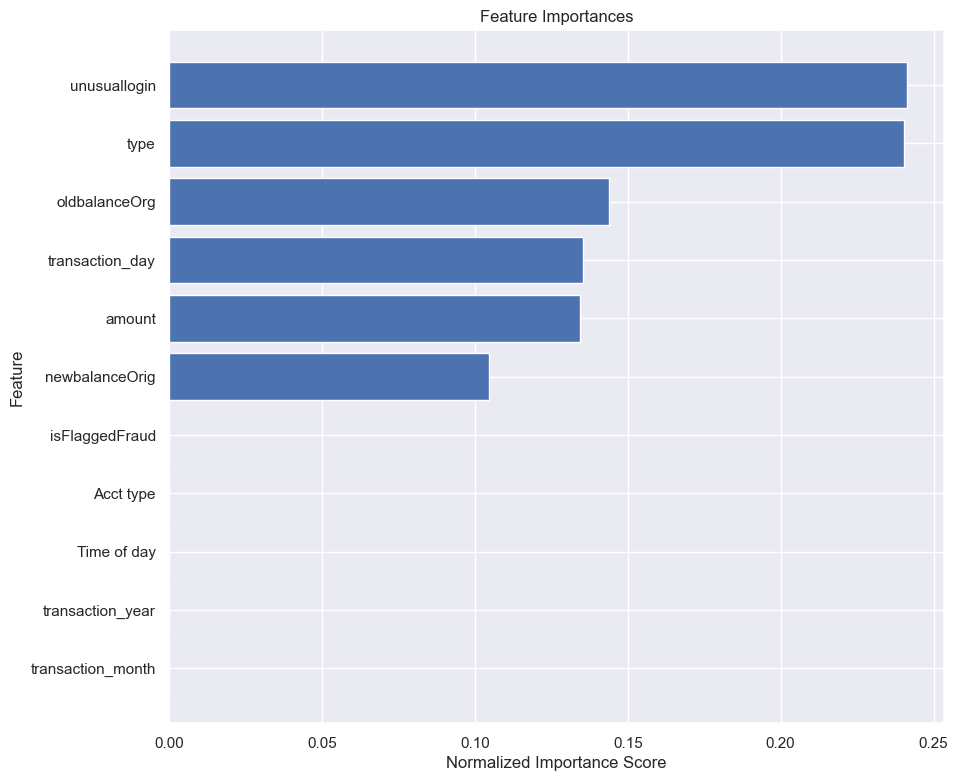

In [31]:
import matplotlib.pyplot as plt

importances = best_xgb_model.feature_importances_


importances = importances / importances.sum()

importance_df = pd.DataFrame({
        'Feature':  X_train.columns,
        'Importance': importances
    }).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 9))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.title("Feature Importances")
plt.xlabel("Normalized Importance Score")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

In [32]:
importance_df

,Feature,Importance
4,unusuallogin,0.241389
0,type,0.240457
2,oldbalanceOrg,0.143977
10,transaction_day,0.135304
1,amount,0.134254
3,newbalanceOrig,0.104620
5,isFlaggedFraud,0.000000
6,Acct type,0.000000
7,Time of day,0.000000
8,transaction_year,0.000000


In [33]:
# Extract features with importance between 1%-35%
important_features_df = importance_df[importance_df['Importance'] > 0.01]

print("Features with Importance > 1%:")
important_features_df

Features with Importance > 1%:


,Feature,Importance
4,unusuallogin,0.241389
0,type,0.240457
2,oldbalanceOrg,0.143977
10,transaction_day,0.135304
1,amount,0.134254
3,newbalanceOrig,0.104620


In [34]:
important_features_df.Feature.tolist()

['unusuallogin',
 'type',
 'oldbalanceOrg',
 'transaction_day',
 'amount',
 'newbalanceOrig']

SHAP Values Summary (Selected Features)


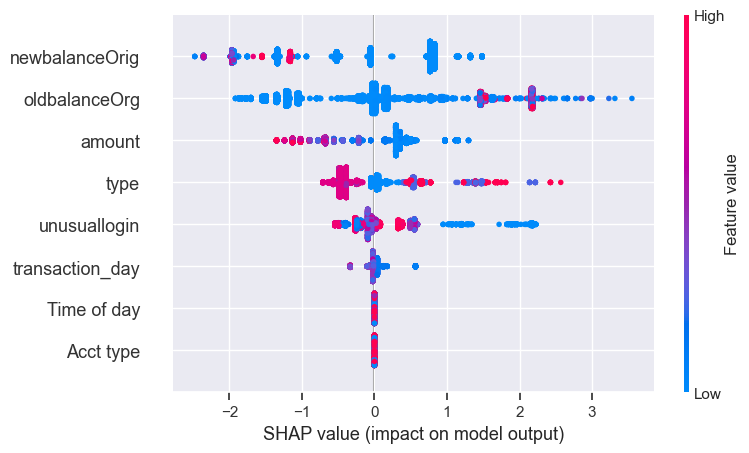

In [35]:
import shap

selected_features = [
    'unusuallogin',
 'oldbalanceOrg',
 'amount',
 'newbalanceOrig',
 'transaction_day',
 'type',
 'Acct type',
 'Time of day'
]


explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(X_train)


shap_df = pd.DataFrame(shap_values, columns=X_train.columns)
shap_selected = shap_df[selected_features]
X_selected = X_train[selected_features]


print("SHAP Values Summary (Selected Features)")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_selected.values, X_selected, show=False)
plt.tight_layout()
plt.show()

In [37]:
new_inputs = important_features_df['Feature'].tolist()

new_inputs

['unusuallogin',
 'type',
 'oldbalanceOrg',
 'transaction_day',
 'amount',
 'newbalanceOrig']

In [38]:
fin_input = new_data[important_features_df['Feature'].tolist()]
fin_output = data['isFraud']

X_train_fin, X_test_fin, y_train_fin, y_test_fin = train_test_split(fin_input, fin_output, test_size=0.3, random_state=42)

In [39]:
def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
         # Fraction of the training data to be randomly sampled for each boosting round (to reduce overfitting)
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        # Fraction of features (columns) to be randomly sampled for each tree (adds diversity)
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        # Controls how much gain is needed to make a split; higher = fewer splits (simpler model)
        'gamma': trial.suggest_int('gamma', 0, 10)
    }

    xgb_clf = XGBClassifier(**param)
    auc = cross_val_score(xgb_clf, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc



study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=10)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_xgb_model_fin = XGBClassifier(**best_params)

[I 2026-04-01 08:44:08,492] A new study created in memory with name: no-name-57a94f6d-dcdd-480c-8d6b-640a0b822ffb
[I 2026-04-01 08:44:09,527] Trial 0 finished with value: 0.7933303127723791 and parameters: {'n_estimators': 615, 'learning_rate': 0.036471424717109215, 'max_depth': 8, 'subsample': 0.6046447207944465, 'colsample_bytree': 0.7692442357245044, 'gamma': 8}. Best is trial 0 with value: 0.7933303127723791.
[I 2026-04-01 08:44:10,569] Trial 1 finished with value: 0.7818980180566939 and parameters: {'n_estimators': 446, 'learning_rate': 0.013950947524649013, 'max_depth': 8, 'subsample': 0.8814369078445721, 'colsample_bytree': 0.667015983416771, 'gamma': 1}. Best is trial 0 with value: 0.7933303127723791.
[I 2026-04-01 08:44:10,957] Trial 2 finished with value: 0.7795057581729955 and parameters: {'n_estimators': 121, 'learning_rate': 0.01996990678912765, 'max_depth': 5, 'subsample': 0.696941152798366, 'colsample_bytree': 0.9306255715532623, 'gamma': 0}. Best is trial 0 with value: 

Best trial:
  Value: 0.810
  Params:  {'n_estimators': 93, 'learning_rate': 0.41594696502285455, 'max_depth': 6, 'subsample': 0.7964931323381076, 'colsample_bytree': 0.5626828974854166, 'gamma': 6}


In [40]:
train_and_evaluate_model('Xgb opitimized for selected features', best_xgb_model_fin, X_train_fin, y_train_fin, X_test_fin, y_test_fin)

Model Performance for Xgb opitimized for selected features
Train Gini prob is 69.75066470146234
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      7008
           1       1.00      0.19      0.32        79

    accuracy                           0.99      7087
   macro avg       1.00      0.59      0.66      7087
weighted avg       0.99      0.99      0.99      7087

[[7008    0]
 [  64   15]]
Model Performance for Xgb opitimized for selected features
Test Gini prob is 65.4910611229384
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2999
           1       1.00      0.13      0.23        39

    accuracy                           0.99      3038
   macro avg       0.99      0.56      0.61      3038
weighted avg       0.99      0.99      0.98      3038

[[2999    0]
 [  34    5]]


[0.6975066470146234, 0.6549106112293841]

# 6. Build best model using final inputs

- train best selected model on final inputs , if result is higher than 40% model will proceed into production environment.

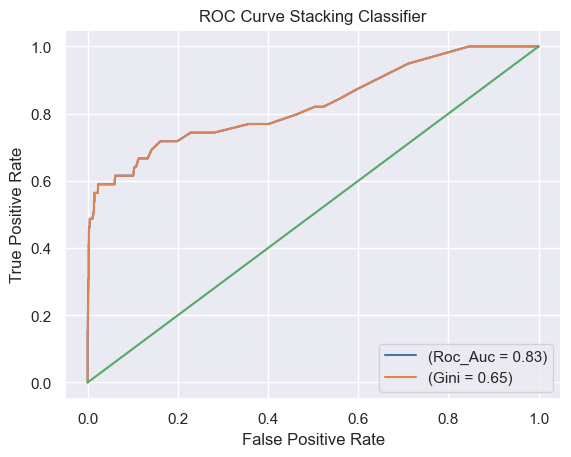

In [55]:

from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve


y_prob_fin = best_xgb_model_fin.predict_proba(X_test_fin)[:,1]

roc_auc = roc_auc_score(y_test_fin, y_prob_fin)
gini = (2*roc_auc_score(y_test_fin, y_prob_fin))-1

fpr, tpr, thresholds = roc_curve(y_test_fin, y_prob_fin)
plt.figure()

plt.plot(fpr, tpr, label='(Roc_Auc = %0.2f)' % roc_auc)
plt.plot(fpr, tpr, label='(Gini = %0.2f)' % gini)
plt.plot([0, 1], [0, 1])
plt.xlim()
plt.ylim()

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Stacking Classifier')

plt.legend(loc='lower right')
plt.show()

# 7. Deployment

- Deploy model on fraud_deploy_data.xlsx
- Create 'probability of fraud' column
- Extract data where 'probability of fraud' is higher than 10%

In [56]:
df=pd.read_excel(r'C:\Users\TOSHIBA\Downloads\fraud_deploy_data.xlsx')
df

,type,branch,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,unusuallogin,isFlaggedFraud,Acct type,Date of transaction,Time of day,id
0,CASH_OUT,Irak,386683.04,C1373577787,0.00,0.00,C33524623,12,0,Savings,7/1/2018,Morning,1
1,PAYMENT,Estados Unidos,504.83,C49365994,608907.09,608402.27,M1529649769,8,0,Savings,13/1/2018,Afternoon,2
2,PAYMENT,Costa de Marfil,9805.46,C480184864,0.00,0.00,M1433956626,19,0,Savings,7/1/2018,Morning,3
3,CASH_OUT,Mexico,54395.20,C391915263,587.49,0.00,C1531333864,9,0,Current,6/1/2018,Afternoon,4
4,PAYMENT,Argelia,24258.10,C247576438,394.00,0.00,M775635860,7,0,Savings,11/1/2018,Night,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,CASH_IN,Mexico,235409.03,C1538844412,10500000.00,10700000.00,C1538745405,13,0,Savings,19/1/2018,Night,1008
1008,CASH_IN,Mexico,29351.64,C853343978,10000000.00,10100000.00,C187649742,20,0,Savings,6/1/2018,Afternoon,1009
1009,CASH_OUT,Turquia,363482.02,C1457226878,25365.85,0.00,C1899073220,7,0,Savings,13/1/2018,Afternoon,1010
1010,CASH_OUT,Alemania,31980.86,C1558129795,0.00,0.00,C257999182,13,0,Savings,7/1/2018,Morning,1011


In [57]:
df.describe(include='all')

,type,branch,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,unusuallogin,isFlaggedFraud,Acct type,Date of transaction,Time of day,id
count,1012,1012,1.012000e+03,1011,1.012000e+03,1.012000e+03,1012,1012.000000,1012.0,1009,1011,1012,1012.000000
unique,5,92,NaN,1011,NaN,NaN,831,NaN,NaN,2,13,3,NaN
top,PAYMENT,Estados Unidos,NaN,C1373577787,NaN,NaN,C985934102,NaN,NaN,Savings,6/1/2018,Afternoon,NaN
freq,555,131,NaN,1,NaN,NaN,8,NaN,NaN,705,134,370,NaN
mean,NaN,NaN,1.002932e+05,NaN,9.662778e+05,9.941229e+05,NaN,10.477273,0.0,NaN,NaN,NaN,506.500000
std,NaN,NaN,2.127360e+05,NaN,2.326172e+06,2.380771e+06,NaN,5.760165,0.0,NaN,NaN,NaN,292.283538
min,NaN,NaN,1.354000e+01,NaN,0.000000e+00,0.000000e+00,NaN,1.000000,0.0,NaN,NaN,NaN,1.000000
25%,NaN,NaN,4.702602e+03,NaN,0.000000e+00,0.000000e+00,NaN,5.000000,0.0,NaN,NaN,NaN,253.750000
50%,NaN,NaN,1.396408e+04,NaN,2.008850e+04,8.557060e+03,NaN,11.000000,0.0,NaN,NaN,NaN,506.500000
75%,NaN,NaN,1.200747e+05,NaN,1.418955e+05,1.580662e+05,NaN,15.000000,0.0,NaN,NaN,NaN,759.250000


In [58]:
df=df.drop(['branch','nameOrig','nameDest'],axis=1)

In [59]:
df['Date of transaction']=pd.to_datetime(df['Date of transaction'], dayfirst=True)

In [60]:
df['transaction_year']=df['Date of transaction'].dt.year
df['transaction_month']=df['Date of transaction'].dt.month
df['transaction_day']=df['Date of transaction'].dt.day
df

,type,amount,oldbalanceOrg,newbalanceOrig,unusuallogin,isFlaggedFraud,Acct type,Date of transaction,Time of day,id,transaction_year,transaction_month,transaction_day
0,CASH_OUT,386683.04,0.00,0.00,12,0,Savings,2018-01-07,Morning,1,2018.0,1.0,7.0
1,PAYMENT,504.83,608907.09,608402.27,8,0,Savings,2018-01-13,Afternoon,2,2018.0,1.0,13.0
2,PAYMENT,9805.46,0.00,0.00,19,0,Savings,2018-01-07,Morning,3,2018.0,1.0,7.0
3,CASH_OUT,54395.20,587.49,0.00,9,0,Current,2018-01-06,Afternoon,4,2018.0,1.0,6.0
4,PAYMENT,24258.10,394.00,0.00,7,0,Savings,2018-01-11,Night,5,2018.0,1.0,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,CASH_IN,235409.03,10500000.00,10700000.00,13,0,Savings,2018-01-19,Night,1008,2018.0,1.0,19.0
1008,CASH_IN,29351.64,10000000.00,10100000.00,20,0,Savings,2018-01-06,Afternoon,1009,2018.0,1.0,6.0
1009,CASH_OUT,363482.02,25365.85,0.00,7,0,Savings,2018-01-13,Afternoon,1010,2018.0,1.0,13.0
1010,CASH_OUT,31980.86,0.00,0.00,13,0,Savings,2018-01-07,Morning,1011,2018.0,1.0,7.0


In [61]:
df=df.drop('Date of transaction',axis=1)

In [65]:
deploy_data=df[['unusuallogin',
 'type',
 'oldbalanceOrg',
 'transaction_day',
 'amount',
 'newbalanceOrig']]
deploy_data

,unusuallogin,type,oldbalanceOrg,transaction_day,amount,newbalanceOrig
0,12,CASH_OUT,0.00,7.0,386683.04,0.00
1,8,PAYMENT,608907.09,13.0,504.83,608402.27
2,19,PAYMENT,0.00,7.0,9805.46,0.00
3,9,CASH_OUT,587.49,6.0,54395.20,0.00
4,7,PAYMENT,394.00,11.0,24258.10,0.00
...,...,...,...,...,...,...
1007,13,CASH_IN,10500000.00,19.0,235409.03,10700000.00
1008,20,CASH_IN,10000000.00,6.0,29351.64,10100000.00
1009,7,CASH_OUT,25365.85,13.0,363482.02,0.00
1010,13,CASH_OUT,0.00,7.0,31980.86,0.00


In [66]:
for i in ['type']:
    le = encoders[i]   # use the encoder fitted on training
    deploy_data[i] = le.fit_transform(deploy_data[i])


deploy_data.head()

,unusuallogin,type,oldbalanceOrg,transaction_day,amount,newbalanceOrig
0,12,1,0.00,7.0,386683.04,0.00
1,8,3,608907.09,13.0,504.83,608402.27
2,19,3,0.00,7.0,9805.46,0.00
3,9,1,587.49,6.0,54395.20,0.00
4,7,3,394.00,11.0,24258.10,0.00


In [67]:
df['probability of fraud'] = best_xgb_model_fin.predict_proba(deploy_data)[:,1]

df

,type,amount,oldbalanceOrg,newbalanceOrig,unusuallogin,isFlaggedFraud,Acct type,Time of day,id,transaction_year,transaction_month,transaction_day,probability of fraud
0,CASH_OUT,386683.04,0.00,0.00,12,0,Savings,Morning,1,2018.0,1.0,7.0,0.006991
1,PAYMENT,504.83,608907.09,608402.27,8,0,Savings,Afternoon,2,2018.0,1.0,13.0,0.003360
2,PAYMENT,9805.46,0.00,0.00,19,0,Savings,Morning,3,2018.0,1.0,7.0,0.003276
3,CASH_OUT,54395.20,587.49,0.00,9,0,Current,Afternoon,4,2018.0,1.0,6.0,0.009869
4,PAYMENT,24258.10,394.00,0.00,7,0,Savings,Night,5,2018.0,1.0,11.0,0.004632
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,CASH_IN,235409.03,10500000.00,10700000.00,13,0,Savings,Night,1008,2018.0,1.0,19.0,0.003395
1008,CASH_IN,29351.64,10000000.00,10100000.00,20,0,Savings,Afternoon,1009,2018.0,1.0,6.0,0.010783
1009,CASH_OUT,363482.02,25365.85,0.00,7,0,Savings,Afternoon,1010,2018.0,1.0,13.0,0.016150
1010,CASH_OUT,31980.86,0.00,0.00,13,0,Savings,Morning,1011,2018.0,1.0,7.0,0.011152
